In [1]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import os
import sys
import STAGATE_pyG
from lib_3d_OT.utils import *

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



In [2]:
adata=sc.read_visium('/home/dbj/mouse/DLPFC/DLPFC/151674/')
adata.var_names_make_unique()
truth = pd.read_csv('/home/dbj/mouse/vision/spatial/DLPFC_annotations/151674_truth.csv', sep='\t', index_col=0)

adata.obs['truth'] = truth.iloc[:,0]
adata = adata[~adata.obs['truth'].isna(), :]
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=3000)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

------Calculating spatial graph...
The graph contains 21122 edges, 3634 cells.
5.8123 neighbors per cell on average.


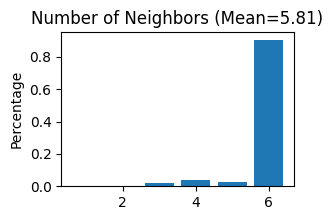

In [3]:
STAGATE_pyG.Cal_Spatial_Net(adata, rad_cutoff=150)
STAGATE_pyG.Stats_Spatial_Net(adata)

In [4]:
adata = STAGATE_pyG.train_STAGATE(adata,n_epochs=1000)
sc.pp.neighbors(adata, use_rep='STAGATE')
sc.tl.umap(adata)

Size of Input:  (3634, 3000)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:06<00:00, 152.72it/s]


In [5]:
adata = STAGATE_pyG.mclust_R(adata, used_obsm='STAGATE', num_cluster=7)

fitting ...
  |======================================================================| 100%


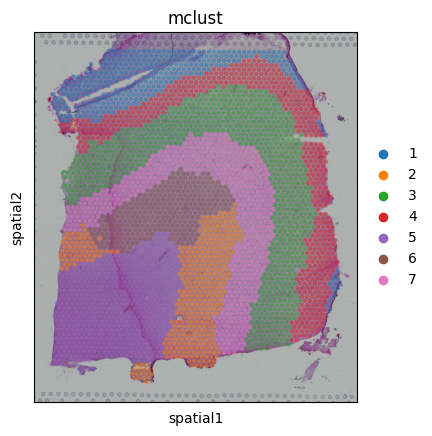

In [8]:
sc.pl.spatial(adata, color='mclust',alpha=0.5, size=1.3)

In [9]:
from sklearn.metrics import adjusted_rand_score,normalized_mutual_info_score
ari = adjusted_rand_score(adata.obs['truth'], adata.obs['mclust'])
nmi = normalized_mutual_info_score(adata.obs['truth'], adata.obs['mclust'])
ari,nmi

(0.6274846251306194, 0.7370916938892719)